In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#loading dataset
ecomm_df = pd.read_csv('ecommerce_data.csv')

In [3]:
ecomm_df.head()


,Purchase_Date,Customer_ID,Gender,Age,Location,Product_Category,Product_ID,Unit_Price,Quantity,Discount_Percent,Payment_Method,Customer_Rating,Return_Status,Total_Spend
0,21-04-2025,46685257,Non-binary,25,East Donald,Electronics,PROD_5506,527.539115,5,0.0,Credit Card,5.0,True,2635.24
1,29-02-2024,8b9d2434,NaN,20,New Roberttown,Electronics,PROD_2535,476.344051,2,0.2,Cash on Delivery,1.0,False,762.42
2,22-02-2024,9a1de644,Non-binary,59,New Jamesside,Automotive,PROD_9928,128.758347,4,0.1,Cash on Delivery,3.0,False,463.49
3,01-11-2024,47378190,Male,66,Port Lindachester,Fashion,PROD_7924,176.722753,4,0.0,PayPal,3.0,False,706.66
4,01-09-2024,f50bea63,Female,24,Curtisfurt,Home & Garden,PROD_6635,183.099179,2,0.0,Crypto,5.0,False,365.98


In [4]:
ecomm_df.describe()

,Age,Unit_Price,Quantity,Discount_Percent,Customer_Rating,Total_Spend
count,5000.000000,5000.000000,5000.000000,5000.000000,4250.000000,5000.000000
mean,49.556800,319.638445,2.979200,0.137050,2.991294,826.692786
std,20.431854,437.461872,1.391242,0.173715,1.396519,1443.964197
min,18.000000,5.076318,1.000000,0.000000,1.000000,-100.000000
25%,34.000000,99.883460,2.000000,0.000000,2.000000,190.272500
50%,49.000000,195.175549,3.000000,0.050000,3.000000,430.780000
75%,65.000000,285.686370,4.000000,0.200000,4.000000,837.390000
max,500.000000,7549.174206,9.000000,0.500000,5.000000,42465.600000


In [5]:
ecomm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Purchase_Date     5000 non-null   object 
 1   Customer_ID       5000 non-null   object 
 2   Gender            4500 non-null   object 
 3   Age               5000 non-null   int64  
 4   Location          5000 non-null   object 
 5   Product_Category  5000 non-null   object 
 6   Product_ID        5000 non-null   object 
 7   Unit_Price        5000 non-null   float64
 8   Quantity          5000 non-null   int64  
 9   Discount_Percent  5000 non-null   float64
 10  Payment_Method    5000 non-null   object 
 11  Customer_Rating   4250 non-null   float64
 12  Return_Status     5000 non-null   bool   
 13  Total_Spend       5000 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 512.8+ KB


In [6]:
ecomm_df.isnull().sum()
#filled in empty cells for customer rating as NA

Purchase_Date         0
Customer_ID           0
Gender              500
Age                   0
Location              0
Product_Category      0
Product_ID            0
Unit_Price            0
Quantity              0
Discount_Percent      0
Payment_Method        0
Customer_Rating     750
Return_Status         0
Total_Spend           0
dtype: int64

In [7]:
ecomm_df["Gender"].unique()

array(['Non-binary', nan, 'Male', 'Female'], dtype=object)

In [8]:
ecomm_df["Gender"] = ecomm_df["Gender"].fillna("Unknown")

In [9]:
ecomm_df["Gender"].isnull().sum()

0

In [10]:
ecomm_df["Gender"].unique()

array(['Non-binary', 'Unknown', 'Male', 'Female'], dtype=object)

In [11]:
ecomm_df.isnull().sum()


Purchase_Date         0
Customer_ID           0
Gender                0
Age                   0
Location              0
Product_Category      0
Product_ID            0
Unit_Price            0
Quantity              0
Discount_Percent      0
Payment_Method        0
Customer_Rating     750
Return_Status         0
Total_Spend           0
dtype: int64

In [12]:
ecomm_df["Rating_Missing"] = (ecomm_df["Customer_Rating"].isna()).astype(int)

In [13]:
median_rating = ecomm_df["Customer_Rating"].median()

ecomm_df["Customer_Rating"] = (ecomm_df["Customer_Rating"].fillna(median_rating))

In [14]:
ecomm_df.isnull().sum()

Purchase_Date       0
Customer_ID         0
Gender              0
Age                 0
Location            0
Product_Category    0
Product_ID          0
Unit_Price          0
Quantity            0
Discount_Percent    0
Payment_Method      0
Customer_Rating     0
Return_Status       0
Total_Spend         0
Rating_Missing      0
dtype: int64

In [15]:
ecomm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Purchase_Date     5000 non-null   object 
 1   Customer_ID       5000 non-null   object 
 2   Gender            5000 non-null   object 
 3   Age               5000 non-null   int64  
 4   Location          5000 non-null   object 
 5   Product_Category  5000 non-null   object 
 6   Product_ID        5000 non-null   object 
 7   Unit_Price        5000 non-null   float64
 8   Quantity          5000 non-null   int64  
 9   Discount_Percent  5000 non-null   float64
 10  Payment_Method    5000 non-null   object 
 11  Customer_Rating   5000 non-null   float64
 12  Return_Status     5000 non-null   bool   
 13  Total_Spend       5000 non-null   float64
 14  Rating_Missing    5000 non-null   int32  
dtypes: bool(1), float64(4), int32(1), int64(2), object(7)
memory usage: 532.4+ KB


In [16]:
ecomm_df = ecomm_df[
    (ecomm_df["Age"] >= 18) &
    (ecomm_df["Age"] <= 100)
]

In [17]:
ecomm_df.describe()

,Age,Unit_Price,Quantity,Discount_Percent,Customer_Rating,Total_Spend,Rating_Missing
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,49.376551,319.645275,2.978992,0.137095,2.993197,826.582309,0.150060
std,18.340853,437.543378,1.391445,0.173734,1.287380,1444.198829,0.357166
min,18.000000,5.076318,1.000000,0.000000,1.000000,-100.000000,0.000000
25%,34.000000,99.876689,2.000000,0.000000,2.000000,190.037500,0.000000
50%,49.000000,195.175549,3.000000,0.050000,3.000000,430.565000,0.000000
75%,65.000000,285.650764,4.000000,0.200000,4.000000,837.315000,0.000000
max,80.000000,7549.174206,9.000000,0.500000,5.000000,42465.600000,1.000000


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, auc, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
import matplotlib.patches as mpatches


import joblib

In [19]:
ecomm_df["Return_Status"].value_counts()

False    4516
True      482
Name: Return_Status, dtype: int64

In [20]:
#converting TRUE/FALSE to integers
ecomm_df["Return_Status"] = ecomm_df["Return_Status"].astype(int)

In [21]:
ecomm_df["Discount_Percent"].describe()

count    4998.000000
mean        0.137095
std         0.173734
min         0.000000
25%         0.000000
50%         0.050000
75%         0.200000
max         0.500000
Name: Discount_Percent, dtype: float64

In [22]:
ecomm_df["Discount_Bucket"] = pd.cut(
    ecomm_df["Discount_Percent"],
    bins=[-0.01, 0, 0.10, 0.25, 1],
    labels=[
        "No Discount",
        "Low",
        "Medium",
        "High"
    ]
)

In [23]:
ecomm_df["Discount_Bucket"].value_counts()

No Discount    1751
Low            1664
High            815
Medium          768
Name: Discount_Bucket, dtype: int64

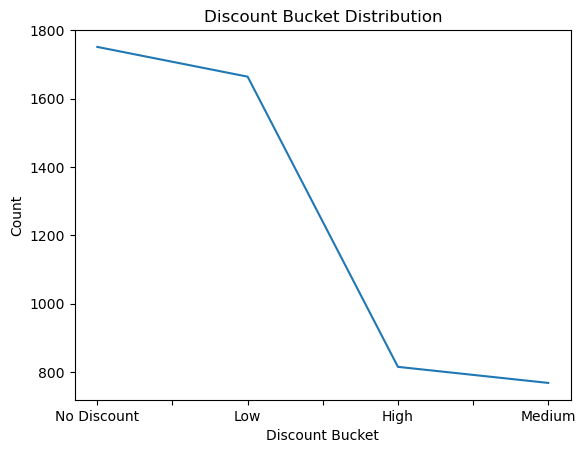

In [24]:
import matplotlib.pyplot as plt

ecomm_df["Discount_Bucket"].value_counts().plot(kind="line")

plt.title("Discount Bucket Distribution")
plt.xlabel("Discount Bucket")
plt.ylabel("Count")

plt.show()

In [25]:
ecomm_df.groupby("Discount_Bucket")["Return_Status"].mean()

Discount_Bucket
No Discount    0.094803
Low            0.101562
Medium         0.089844
High           0.095706
Name: Return_Status, dtype: float64

In [26]:
ecomm_df["Age"].value_counts()

77    102
80    101
42     92
56     92
52     90
     ... 
57     66
48     64
32     64
51     62
34     60
Name: Age, Length: 63, dtype: int64

In [27]:
ecomm_df["Age_Group"] = pd.cut(
    ecomm_df["Age"],
    bins=[17, 25, 35, 50, 100],
    labels=[
        "Young Adults",
        "Adults",
        "Middle Age",
        "Seniors"
    ]
)

In [28]:
ecomm_df["Age_Group"].value_counts()

Seniors         2408
Middle Age      1198
Adults           771
Young Adults     621
Name: Age_Group, dtype: int64

In [29]:
ecomm_df[["Age", "Age_Group"]].head(10)

,Age,Age_Group
0,25,Young Adults
1,20,Young Adults
2,59,Seniors
3,66,Seniors
4,24,Young Adults
5,23,Young Adults
6,20,Young Adults
7,58,Seniors
8,52,Seniors
9,71,Seniors


In [30]:
ecomm_df.head()

,Purchase_Date,Customer_ID,Gender,Age,Location,Product_Category,Product_ID,Unit_Price,Quantity,Discount_Percent,Payment_Method,Customer_Rating,Return_Status,Total_Spend,Rating_Missing,Discount_Bucket,Age_Group
0,21-04-2025,46685257,Non-binary,25,East Donald,Electronics,PROD_5506,527.539115,5,0.0,Credit Card,5.0,1,2635.24,0,No Discount,Young Adults
1,29-02-2024,8b9d2434,Unknown,20,New Roberttown,Electronics,PROD_2535,476.344051,2,0.2,Cash on Delivery,1.0,0,762.42,0,Medium,Young Adults
2,22-02-2024,9a1de644,Non-binary,59,New Jamesside,Automotive,PROD_9928,128.758347,4,0.1,Cash on Delivery,3.0,0,463.49,0,Low,Seniors
3,01-11-2024,47378190,Male,66,Port Lindachester,Fashion,PROD_7924,176.722753,4,0.0,PayPal,3.0,0,706.66,0,No Discount,Seniors
4,01-09-2024,f50bea63,Female,24,Curtisfurt,Home & Garden,PROD_6635,183.099179,2,0.0,Crypto,5.0,0,365.98,0,No Discount,Young Adults


In [31]:
ecomm_df["Location"].value_counts()

North David            7
North Michael          7
Robertmouth            6
Davischester           5
South Michael          5
                      ..
East Jefferystad       1
Port Ricardo           1
Lake Danieltown        1
Stanleymouth           1
West Christinashire    1
Name: Location, Length: 4308, dtype: int64

In [32]:
ecomm_df.groupby("Location")["Return_Status"].mean().sort_values(ascending=False)

Location
Jessicaville          1.0
Melissachester        1.0
Garrettport           1.0
Curryshire            1.0
Cummingsborough       1.0
                     ... 
Lake Cynthiashire     0.0
Lake Daniel           0.0
Lake Danielchester    0.0
Lake Danielle         0.0
Zimmermanstad         0.0
Name: Return_Status, Length: 4308, dtype: float64

In [34]:
ecomm_df["Rating_Missing"].value_counts()

0    4248
1     750
Name: Rating_Missing, dtype: int64

In [35]:
x = ecomm_df.drop(columns=['Customer_ID', 'Product_ID','Purchase_Date','Location','Return_Status'])
y = ecomm_df['Return_Status']

In [36]:
x = pd.get_dummies(x, drop_first=True)

In [37]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4998 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             4998 non-null   int64  
 1   Unit_Price                      4998 non-null   float64
 2   Quantity                        4998 non-null   int64  
 3   Discount_Percent                4998 non-null   float64
 4   Customer_Rating                 4998 non-null   float64
 5   Total_Spend                     4998 non-null   float64
 6   Rating_Missing                  4998 non-null   int32  
 7   Gender_Male                     4998 non-null   uint8  
 8   Gender_Non-binary               4998 non-null   uint8  
 9   Gender_Unknown                  4998 non-null   uint8  
 10  Product_Category_Beauty         4998 non-null   uint8  
 11  Product_Category_Electrnx       4998 non-null   uint8  
 12  Product_Category_Electronics    49

In [39]:
x.isnull().sum().sort_values(ascending=False)

Age                               0
Unit_Price                        0
Age_Group_Middle Age              0
Age_Group_Adults                  0
Discount_Bucket_High              0
Discount_Bucket_Medium            0
Discount_Bucket_Low               0
Payment_Method_PayPal             0
Payment_Method_Debit Card         0
Payment_Method_Crypto             0
Payment_Method_Credit Card        0
Product_Category_Sports           0
Product_Category_Home & Garden    0
Product_Category_Fashion          0
Product_Category_Electronics      0
Product_Category_Electrnx         0
Product_Category_Beauty           0
Gender_Unknown                    0
Gender_Non-binary                 0
Gender_Male                       0
Rating_Missing                    0
Total_Spend                       0
Customer_Rating                   0
Discount_Percent                  0
Quantity                          0
Age_Group_Seniors                 0
dtype: int64

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42, stratify=y)

In [41]:
print("\nTraining set target distribution:")
print(y_train.value_counts())

print("\nTest set target distribution:")
print(y_test.value_counts())


Training set target distribution:
0    3161
1     337
Name: Return_Status, dtype: int64

Test set target distribution:
0    1355
1     145
Name: Return_Status, dtype: int64


In [42]:
scaler = StandardScaler()

x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns,
    index=x_test.index
)

In [43]:
logr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

logr.fit(x_train_scaled, y_train)

print("\nModel intercept:", logr.intercept_)
print("Model coefficients:", logr.coef_)


Model intercept: [-0.04527822]
Model coefficients: [[ 0.02399894 -0.08193462  0.0411088   0.71275426  0.08667593 -0.02892988
   0.03746758 -0.19433019 -0.10191615 -0.14439982  0.05271972  0.09981764
   0.14300179 -0.0216548  -0.05986694  0.0041501   0.09932923  0.05936389
   0.05555761  0.01098266 -0.09934564 -0.31574362 -0.75617841 -0.02747765
  -0.16122014  0.01646557]]


In [44]:
y_pred = logr.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('F1 score: ', f1_score(y_test, y_pred))


Accuracy: 0.526
F1 score:  0.16056670602125148


In [45]:
y_pred_prob = logr.predict_proba(x_test_scaled)[:, 1]
auc_logr = round(roc_auc_score(y_test, y_pred_prob),5)
print('AUROC:' , auc_logr)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

AUROC: 0.50756

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.53      0.67      1355
           1       0.10      0.47      0.16       145

    accuracy                           0.53      1500
   macro avg       0.50      0.50      0.42      1500
weighted avg       0.83      0.53      0.62      1500



In [51]:
ecomm_df.groupby("Payment_Method")["Return_Status"].mean()

Payment_Method
Cash on Delivery    0.087683
Credit Card         0.113772
Crypto              0.099609
Debit Card          0.094898
PayPal              0.086074
Name: Return_Status, dtype: float64

In [47]:
ecomm_df.groupby("Customer_Rating")["Return_Status"].mean()

Customer_Rating
1.0    0.090253
2.0    0.090278
3.0    0.101737
4.0    0.098876
5.0    0.096130
Name: Return_Status, dtype: float64

In [48]:
ecomm_df.groupby("Product_Category")["Return_Status"].mean()

Product_Category
Automotive       0.088639
Beauty           0.098976
Electrnx         0.400000
Electronics      0.109589
Fashion          0.084559
Home & Garden    0.089180
Sports           0.103774
Name: Return_Status, dtype: float64

In [49]:
ecomm_df["Product_Category"].value_counts()

Beauty           879
Sports           848
Home & Garden    841
Fashion          816
Electronics      803
Automotive       801
Electrnx          10
Name: Product_Category, dtype: int64

In [52]:
ecomm_df["Product_Category"] = ecomm_df["Product_Category"].replace(
    "Electrnx", 
    "Electronics"
)

In [53]:
ecomm_df["Product_Category"].value_counts()

Beauty           879
Sports           848
Home & Garden    841
Fashion          816
Electronics      813
Automotive       801
Name: Product_Category, dtype: int64

In [54]:
ecomm_df.isnull().sum()


Purchase_Date       0
Customer_ID         0
Gender              0
Age                 0
Location            0
Product_Category    0
Product_ID          0
Unit_Price          0
Quantity            0
Discount_Percent    0
Payment_Method      0
Customer_Rating     0
Return_Status       0
Total_Spend         0
Rating_Missing      0
Discount_Bucket     0
Age_Group           0
dtype: int64

In [55]:
ecomm_df.to_csv("ecommerce_cleaned.csv", index=False)